# Analyse des trajectoires de prise en charge — projet de démonstration

**Objectif :** ce notebook illustre une démarche d'analyse de données proche de celle menée par le programme IDASE de L'Action Tank : appariement de bases de données, analyse descriptive et analyse multivariée d'un phénomène social.

⚠️ **Note importante :** les données utilisées ici sont **entièrement simulées** (générées aléatoirement) à des fins de démonstration de méthode. Elles ne proviennent d'aucune source réelle et ne doivent pas être interprétées comme des statistiques officielles.

**Auteure :** Syrine Mlika
**Compétences illustrées :** Python (pandas, numpy, scikit-learn, statsmodels), nettoyage et appariement de bases, statistiques descriptives, régression logistique (analyse multivariée), visualisation, discussion critique sur la causalité.

## 1. Import des librairies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)


## 2. Génération des données (simulation de deux bases à apparier)

On simule deux tables, comme dans un vrai projet de croisement de bases :
- `beneficiaires` : une ligne par enfant suivi, avec des caractéristiques individuelles et un code département
- `departements` : des indicateurs socio-économiques par département

Ces deux tables seront ensuite **appariées (jointure)** sur le code département, une pratique explicitement mentionnée dans l'offre.

In [2]:
n = 600

departements = pd.DataFrame({
    "code_dept": [f"D{str(i).zfill(2)}" for i in range(1, 21)],
    "taux_pauvrete_pct": np.round(np.random.normal(15, 4, 20).clip(5, 30), 1),
    "population_milliers": np.round(np.random.uniform(150, 2500, 20), 0),
})

beneficiaires = pd.DataFrame({
    "id": range(1, n + 1),
    "code_dept": np.random.choice(departements["code_dept"], n),
    "age_entree": np.random.randint(0, 18, n),
    "duree_prise_en_charge_mois": np.round(np.random.gamma(shape=2.2, scale=10, size=n), 1),
    "type_placement": np.random.choice(
        ["Famille d'accueil", "Établissement", "Accompagnement à domicile"],
        n, p=[0.45, 0.30, 0.25]
    ),
})

# On simule un motif de sortie corrélé (de façon volontairement bruitée) à l'âge, la durée et la pauvreté du département,
# pour avoir un signal exploitable en régression logistique.
tmp = beneficiaires.merge(departements, on="code_dept")
score = (
    -0.05 * tmp["age_entree"]
    - 0.02 * tmp["duree_prise_en_charge_mois"]
    - 0.04 * tmp["taux_pauvrete_pct"]
    + np.random.normal(0, 1, n)
)
proba_reunification = 1 / (1 + np.exp(-score))
beneficiaires["motif_sortie"] = np.where(
    np.random.rand(n) < proba_reunification, "Réunification familiale", "Autre orientation"
)

beneficiaires.head()


,id,code_dept,age_entree,duree_prise_en_charge_mois,type_placement,motif_sortie
0,1,D04,0,21.0,Famille d'accueil,Autre orientation
1,2,D18,11,26.2,Accompagnement à domicile,Autre orientation
2,3,D08,4,11.2,Accompagnement à domicile,Autre orientation
3,4,D04,16,12.3,Établissement,Autre orientation
4,5,D02,15,11.2,Établissement,Autre orientation


## 3. Nettoyage et appariement des bases

In [3]:
print("Valeurs manquantes - bénéficiaires :\n", beneficiaires.isna().sum())
print("\nValeurs manquantes - départements :\n", departements.isna().sum())

# Jointure (appariement) des deux bases sur le code département
df = beneficiaires.merge(departements, on="code_dept", how="left")
assert df["taux_pauvrete_pct"].isna().sum() == 0, "Appariement incomplet"
print(f"\n{len(df)} lignes après appariement, {df['code_dept'].nunique()} départements représentés.")
df.head()


Valeurs manquantes - bénéficiaires :
 id                            0
code_dept                     0
age_entree                    0
duree_prise_en_charge_mois    0
type_placement                0
motif_sortie                  0
dtype: int64

Valeurs manquantes - départements :
 code_dept              0
taux_pauvrete_pct      0
population_milliers    0
dtype: int64

600 lignes après appariement, 20 départements représentés.


,id,code_dept,age_entree,duree_prise_en_charge_mois,type_placement,motif_sortie,taux_pauvrete_pct,population_milliers
0,1,D04,0,21.0,Famille d'accueil,Autre orientation,21.1,1358.0
1,2,D18,11,26.2,Accompagnement à domicile,Autre orientation,16.3,1314.0
2,3,D08,4,11.2,Accompagnement à domicile,Autre orientation,18.1,551.0
3,4,D04,16,12.3,Établissement,Autre orientation,21.1,1358.0
4,5,D02,15,11.2,Établissement,Autre orientation,14.4,1995.0


## 4. Statistiques descriptives

In [4]:
df.groupby("type_placement")["duree_prise_en_charge_mois"].describe()[["mean", "50%", "std", "count"]]


,mean,50%,std,count
type_placement,,,,
Accompagnement à domicile,25.226875,21.80,15.466233,160.0
Famille d'accueil,21.355109,18.15,14.131584,274.0
Établissement,23.784337,19.70,15.621640,166.0


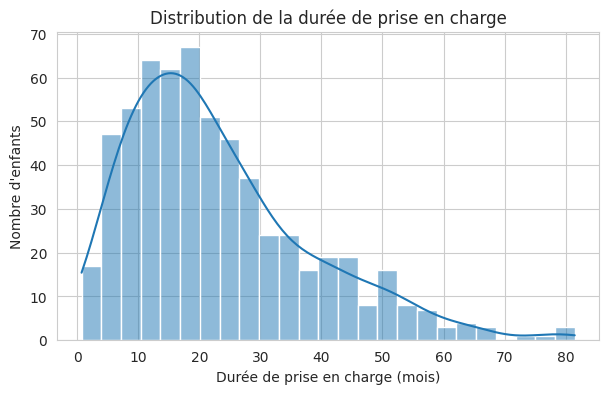

In [5]:
fig, ax = plt.subplots()
sns.histplot(df["duree_prise_en_charge_mois"], bins=25, kde=True, ax=ax)
ax.set_xlabel("Durée de prise en charge (mois)")
ax.set_ylabel("Nombre d'enfants")
ax.set_title("Distribution de la durée de prise en charge")
plt.show()


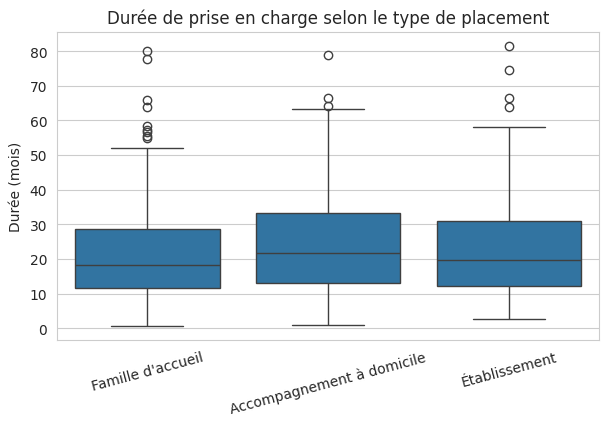

In [6]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="type_placement", y="duree_prise_en_charge_mois", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Durée (mois)")
ax.set_title("Durée de prise en charge selon le type de placement")
plt.xticks(rotation=15)
plt.show()


## 5. Analyse multivariée : régression logistique

On cherche à savoir si l'âge à l'entrée, la durée de prise en charge et le taux de pauvreté du département sont associés à la probabilité d'une réunification familiale, **toutes choses égales par ailleurs** — c'est le principe de l'analyse multivariée : isoler l'effet propre de chaque variable.

In [7]:
df["reunification"] = (df["motif_sortie"] == "Réunification familiale").astype(int)

X = df[["age_entree", "duree_prise_en_charge_mois", "taux_pauvrete_pct"]]
X = sm.add_constant(X)
y = df["reunification"]

model = sm.Logit(y, X).fit(disp=0)
print(model.summary())


                           Logit Regression Results                           
Dep. Variable:          reunification   No. Observations:                  600
Model:                          Logit   Df Residuals:                      596
Method:                           MLE   Df Model:                            3
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                 0.04655
Time:                        10:22:29   Log-Likelihood:                -325.82
converged:                       True   LL-Null:                       -341.72
Covariance Type:            nonrobust   LLR p-value:                 5.730e-07
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.6286      0.449      1.400      0.162      -0.252       1.509
age_entree                    -0.0733      0.019     -3.895      0.000      -0.110 

In [8]:
odds_ratios = np.exp(model.params).rename("odds_ratio")
conf = np.exp(model.conf_int())
conf.columns = ["ic_bas", "ic_haut"]
pd.concat([odds_ratios, conf, model.pvalues.rename("p_value")], axis=1).round(3)


,odds_ratio,ic_bas,ic_haut,p_value
const,1.875,0.777,4.521,0.162
age_entree,0.929,0.896,0.964,0.000
duree_prise_en_charge_mois,0.976,0.962,0.990,0.001
taux_pauvrete_pct,0.960,0.911,1.012,0.133


## 6. Limites et discussion sur la causalité

Quelques points qu'il est important de garder à l'esprit — et que je mettrais en avant dans un vrai projet :

- **Corrélation ≠ causalité.** Une association entre le taux de pauvreté départemental et le motif de sortie ne permet pas de conclure à un effet causal : des facteurs non observés (politiques locales, moyens des services sociaux, composition démographique) peuvent confondre la relation.
- **Variables omises.** Un modèle plus complet inclurait des variables sur le contexte familial, l'historique de prise en charge, ou des effets fixes par département.
- **Pour aller vers une analyse causale**, des méthodes comme le matching, les doubles différences ou les variables instrumentales seraient nécessaires selon la question posée et les données disponibles.
- Ce notebook a une vocation **méthodologique** : la même structure (appariement → description → modèle multivarié → discussion des limites) s'applique directement à des données réelles de type IDASE.